<div align="center">
<h1 style="color:green; font-weight:700;text-decoration:underline;"> ~ MINI PROJECT - 5 ~ </h1>
</div>

<div align="center">
<h1 style="color:purple; font-weight:700;text-decoration:underline;"> ~ MODULE - EDA ~</h1>
</div>

<div align="center">
<h1 style="color:BROWN; font-weight:700;text-decoration:underline; text-transform: uppercase"> ~ TOPIC - Exploratory Data Analysis (EDA) on Shark Tank India Dataset ~ </h1>
</div>

In [2]:
# Loading of the data 
import pandas as pd

df = pd.read_csv('EDA_Shark_Tank_India.csv')
display(df.head())


,episode_number,pitch_number,brand_name,idea,deal,pitcher_ask_amount,ask_equity,ask_valuation,deal_amount,deal_equity,...,ashneer_deal,anupam_deal,aman_deal,namita_deal,vineeta_deal,peyush_deal,ghazal_deal,total_sharks_invested,amount_per_shark,equity_per_shark
0,1,1,BluePine Industries,Frozen Momos,1,50.0,5.0,1000.00,75.0,16.00,...,1,0,1,0,1,0,0,3,25.0,5.333333333
1,1,2,Booz scooters,Renting e-bike for mobility in private spaces,,40.0,15.0,266.67,40.0,50.00,...,1,0,0,0,1,0,0,2,20.0,25
2,1,3,Heart up my Sleeves,Detachable Sleeves,1,25.0,10.0,250.00,25.0,30.00,...,0,1,0,0,1,0,0,2,12.5,
3,2,4,Tagz Foods,Healthy Potato Chips,1,70.0,1.0,7000.00,70.0,2.75,...,1,0,0,0,0,0,0,1,70.0,2.75
4,2,5,Head and Heart,Brain Development Course,0,50.0,5.0,1000.00,0.0,0.00,...,0,0,0,0,0,0,0,0,0.0,0


<div align="center">
<h3 style="color: black; font-weight:700;text-decoration:underline;"> ---- Data Cleaning ---- </h3>
</div>

In [3]:
# Identification of Missing values and proper handling of them.

missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)


Missing values per column:
episode_number           0
pitch_number             0
brand_name               0
idea                     0
deal                     0
pitcher_ask_amount       0
ask_equity               0
ask_valuation            0
deal_amount              0
deal_equity              0
deal_valuation           0
ashneer_present          0
anupam_present           0
aman_present             0
namita_present           0
vineeta_present          0
peyush_present           0
ghazal_present           0
ashneer_deal             0
anupam_deal              0
aman_deal                0
namita_deal              0
vineeta_deal             0
peyush_deal              0
ghazal_deal              0
total_sharks_invested    0
amount_per_shark         0
equity_per_shark         0
dtype: int64


In [4]:
# Identification and handling of any duplicate records if present.

duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
  df = df.drop_duplicates()
  print("Duplicate rows removed.")

duplicate_rows_after_removal = df.duplicated().sum()
print(f"Number of duplicate rows after removal: {duplicate_rows_after_removal}")


Number of duplicate rows: 1
Duplicate rows removed.
Number of duplicate rows after removal: 0


In [5]:
# Convertion of data types if necessary.

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 118 entries, 0 to 118
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   episode_number         118 non-null    int64  
 1   pitch_number           118 non-null    int64  
 2   brand_name             118 non-null    object 
 3   idea                   118 non-null    object 
 4   deal                   118 non-null    object 
 5   pitcher_ask_amount     118 non-null    float64
 6   ask_equity             118 non-null    float64
 7   ask_valuation          118 non-null    float64
 8   deal_amount            118 non-null    float64
 9   deal_equity            118 non-null    float64
 10  deal_valuation         118 non-null    float64
 11  ashneer_present        118 non-null    int64  
 12  anupam_present         118 non-null    int64  
 13  aman_present           118 non-null    int64  
 14  namita_present         118 non-null    int64  
 15  vineeta_pre

 #### The `'deal'` and `'equity_per_shark'` columns are of object type but appear to contain numerical data. These columns should be converted to a numeric type for analysis.

In [6]:
# Converted.
df['deal'] = pd.to_numeric(df['deal'], errors='coerce')
df['equity_per_shark'] = pd.to_numeric(df['equity_per_shark'], errors='coerce')
display(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 118 entries, 0 to 118
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   episode_number         118 non-null    int64  
 1   pitch_number           118 non-null    int64  
 2   brand_name             118 non-null    object 
 3   idea                   118 non-null    object 
 4   deal                   116 non-null    float64
 5   pitcher_ask_amount     118 non-null    float64
 6   ask_equity             118 non-null    float64
 7   ask_valuation          118 non-null    float64
 8   deal_amount            118 non-null    float64
 9   deal_equity            118 non-null    float64
 10  deal_valuation         118 non-null    float64
 11  ashneer_present        118 non-null    int64  
 12  anupam_present         118 non-null    int64  
 13  aman_present           118 non-null    int64  
 14  namita_present         118 non-null    int64  
 15  vineeta_pre

None

<div align="center">
<h3 style="color: black; font-weight:700;text-decoration:underline;"> ---- Project Questions ---- </h3>
</div>

- #### 1.	How many deals were successfully made and what percentage of total pitches did they constitute?
- #### 2.	What is the average and median deal_amount for pitches that received investment?
- #### 3.	Which shark has made the highest number of investments? Provide a visualization of top 3 sharks.
- #### 4.	What is the total amount invested by all sharks combined in entire season.
- #### 5.	How does the deal_equity distribution look? Are there any outliers?
- #### 6.	Find the correlation between deal_valuation and ask_valuation. What insight can be drawn from this?
- #### 7.	What is the average equity percentage given to the sharks per deal?
- #### 8.	Identify which episode had the highest number of deals and visualize it.
- #### 9.	How many pitches asked for more than ₹1 crore and how many of those received investments?
- #### 10.	What percentage of pitches involved more than one shark investing together?
- #### 11.	How does the investment behavior of Ashneer Grover compare with Peyush Bansal in terms of total amount invested?
- #### 12.	Create a box plot to analyze amount_per_shark. What insights can be gathered?
- #### 13.	Are there any cases where the deal_amount exceeded the pitcher_ask_amount? If yes, list those cases.
- #### 14.	Which shark has the highest return on investment (ROI) based on deal_amount vs. deal_equity?
- #### 15.	Identify trends in equity distribution—are sharks investing in lower or higher equity stakes over time?
- #### 16.	What is the relationship between pitcher_ask_amount and deal_amount? Do pitchers who ask for less tend to secure more deals?
- #### 17.	Identify if there is a pattern in episode-wise deal closures—do certain episodes see more investments?
- #### 18.	Analyze the impact of equity dilution on deal_valuation. Are lower equity asks leading to higher deal valuations?
-------------------------


<div align="center">
<h3 style="color: black; font-weight:700;text-decoration:underline;"> ---- Solutions ---- </h3>
</div>


<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 1. Calculation of the number and percentage of successful deals. </h4>
</div>

In [7]:
successful_deals = df[df['deal'] > 0].shape[0]
total_pitches = df.shape[0]
percentage_successful_deals = (successful_deals / total_pitches) * 100

print(f"Number of successful deals: {successful_deals}")
print(f"Percentage of successful deals: {percentage_successful_deals:.2f}%")


Number of successful deals: 64
Percentage of successful deals: 54.24%



<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 2. Average and median deal_amount for pitches that received investment.</h4>
</div>

In [8]:

successful_deals_df = df[df['deal'] > 0].copy()
average_deal_amount = successful_deals_df['deal_amount'].mean()
median_deal_amount = successful_deals_df['deal_amount'].median()

print(f"Average deal amount for successful pitches: {average_deal_amount:.2f}")
print(f"Median deal amount for successful pitches: {median_deal_amount:.2f}")

Average deal amount for successful pitches: 55.11
Median deal amount for successful pitches: 50.00



<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 3. Shark that has made the highest number of investments. Visualization of the top 3. </h4>
</div>

In [9]:

import matplotlib.pyplot as plt

shark_deal_columns = ['ashneer_deal', 'anupam_deal', 'aman_deal', 'namita_deal', 'vineeta_deal', 'peyush_deal', 'ghazal_deal']
shark_investments = df[shark_deal_columns].sum()
top_3_sharks = shark_investments.sort_values(ascending=False).head(3)
top_3_sharks


aman_deal      28
peyush_deal    27
anupam_deal    25
dtype: int64

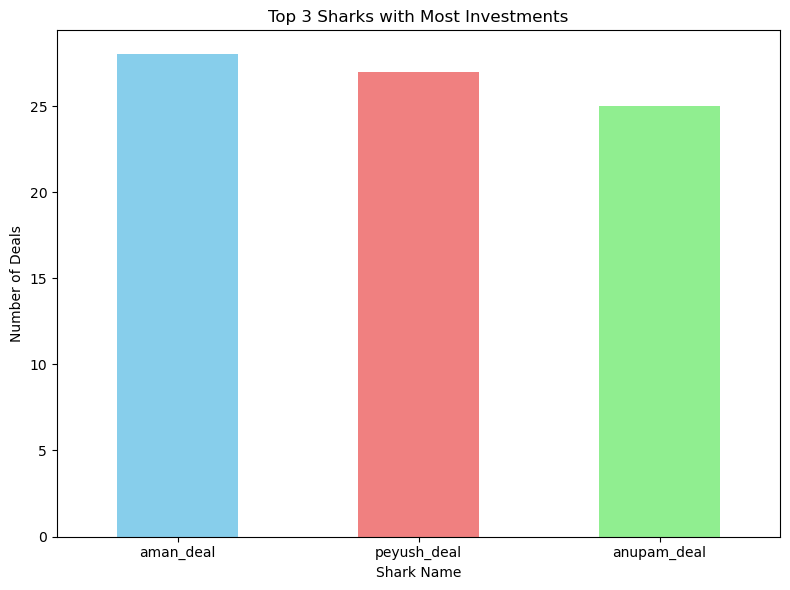

In [10]:

plt.figure(figsize=(8, 6))
top_3_sharks.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Top 3 Sharks with Most Investments')
plt.xlabel('Shark Name')
plt.ylabel('Number of Deals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 4. Total amount invested by all sharks combined in entire season. </h4>
</div>

In [11]:

total_investment_amount = df['deal_amount'].sum()
print(f"Total amount invested by all sharks: {total_investment_amount:.2f}")


Total amount invested by all sharks: 3767.00



<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 5. Analysis of Deal_equity distribution and the outliers if any. </h4>
</div>

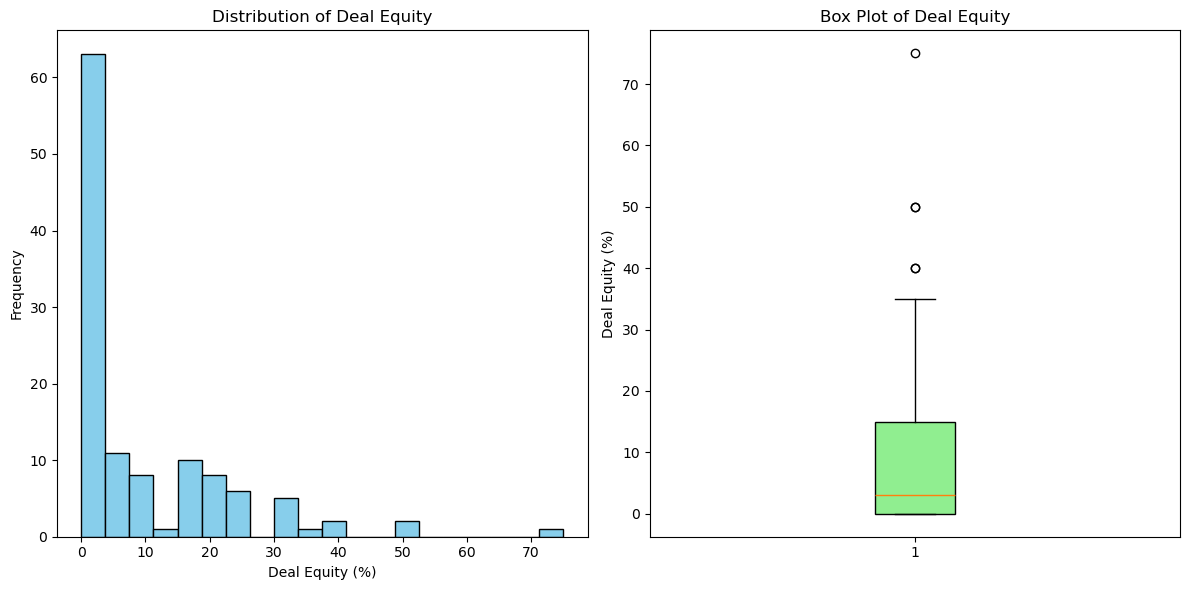

Q1 (25th percentile): 0.00
Q3 (75th percentile): 15.00
IQR: 15.00
Lower bound for outliers: -22.50
Upper bound for outliers: 37.50

Outliers in 'deal_equity' column:


,brand_name,deal_equity
1,Booz scooters,50.0
43,Hammer Lifestyle,40.0
66,Sid07 Designs,75.0
77,KG Agrotech,40.0
82,Isak Fragrances,50.0


In [12]:

import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df['deal_equity'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Deal Equity')
plt.xlabel('Deal Equity (%)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(df['deal_equity'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('Box Plot of Deal Equity')
plt.ylabel('Deal Equity (%)')

plt.tight_layout()
plt.show()

Q1 = df['deal_equity'].quantile(0.25)
Q3 = df['deal_equity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['deal_equity'] < lower_bound) | (df['deal_equity'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound for outliers: {lower_bound:.2f}")
print(f"Upper bound for outliers: {upper_bound:.2f}")

print("\nOutliers in 'deal_equity' column:")
display(outliers[['brand_name', 'deal_equity']])


### Yes, there are outliers.


<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 6. Correlation between deal_valuation and ask_valuation. Insights. </h4>
</div>

In [13]:

correlation = df['deal_valuation'].corr(df['ask_valuation'])
print(f"Correlation between Deal Valuation and Ask Valuation: {correlation:.2f}")


Correlation between Deal Valuation and Ask Valuation: 0.02


##### There is a very weak positive linear relationship between the valuation asked by the pitchers and the final valuation agreed upon in the deals. This means that the initial valuation requested by the entrepreneurs had almost no linear correlation with the valuation they received in the successful deals. In other words, asking for a higher or lower valuation did not strongly predict whether they would get a higher or lower valuation in the final deal.
-------


<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 7. Average equity percentage given to the sharks per deal. </h4>
</div>

In [14]:

average_equity_percentage = df['deal_equity'].mean()
print(f"Average equity percentage per deal: {average_equity_percentage:.2f}%")


Average equity percentage per deal: 9.14%



<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 8. Episodes which had the highest number of deals and visualization of it.</h4>
</div>

Episodes with the highest number of deals (3 deals):


,episode_number,number_of_deals
0,1,3
7,8,3
9,10,3
12,13,3
14,15,3
15,16,3
16,17,3
20,21,3
32,33,3


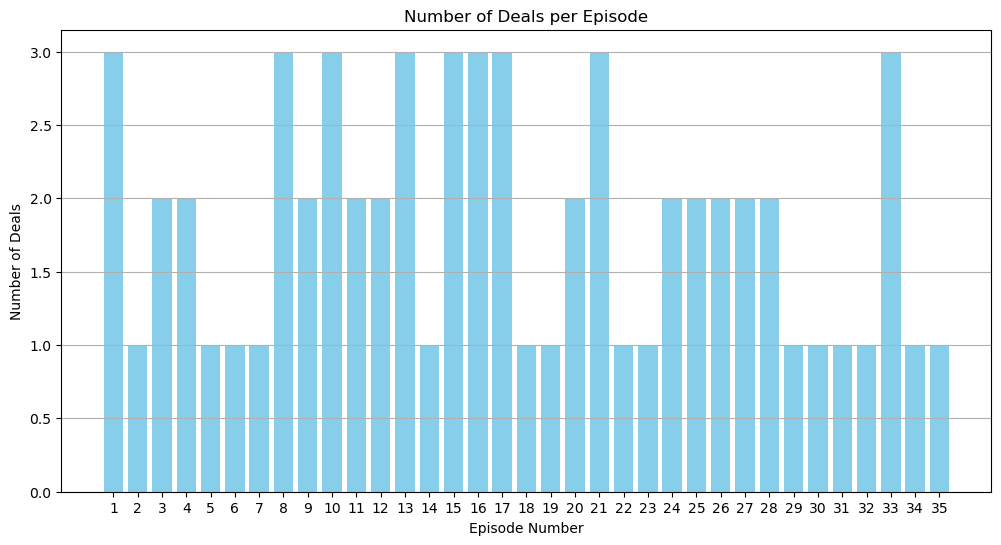

In [15]:
import matplotlib.pyplot as plt

successful_deals_df = df[df['deal'] > 0].copy()
deals_per_episode = successful_deals_df.groupby('episode_number').size().reset_index(name='number_of_deals')

max_deals = deals_per_episode['number_of_deals'].max()
episodes_with_max_deals = deals_per_episode[deals_per_episode['number_of_deals'] == max_deals]

print(f"Episodes with the highest number of deals ({max_deals} deals):")
display(episodes_with_max_deals)


plt.figure(figsize=(12, 6))
plt.bar(deals_per_episode['episode_number'], deals_per_episode['number_of_deals'], color='skyblue')
plt.title('Number of Deals per Episode')
plt.xlabel('Episode Number')
plt.ylabel('Number of Deals')
plt.xticks(deals_per_episode['episode_number'])
plt.grid(axis='y')
plt.show()


<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 9. Pitches asked for more than ₹1 crore and those who have received investments. </h4>
</div>

In [16]:

high_ask_pitches = df[df['pitcher_ask_amount'] > 100]
num_high_ask_pitches = high_ask_pitches.shape[0]

high_ask_deals = high_ask_pitches[high_ask_pitches['deal'] > 0]
num_high_ask_deals = high_ask_deals.shape[0]

print(f"Number of pitches that asked for more than ₹1 crore: {num_high_ask_pitches}")
print(f"Number of those pitches that received investments: {num_high_ask_deals}")


Number of pitches that asked for more than ₹1 crore: 7
Number of those pitches that received investments: 1



<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 10. Percentage of pitches involved more than one shark investing together. </h4>
</div>

In [17]:

pitches_with_multiple_sharks = df[df['total_sharks_invested'] > 1].shape[0]
total_pitches = df.shape[0]
percentage_multi_shark_deals = (pitches_with_multiple_sharks / total_pitches) * 100

print(f"Percentage of pitches with more than one shark investing: {percentage_multi_shark_deals:.2f}%")


Percentage of pitches with more than one shark investing: 37.29%



<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 11. The investment behavior of Ashneer Grover compare with Peyush Bansal in terms of total amount invested. </h4>
</div>

In [18]:

ashneer_deals_df = df[df['ashneer_deal'] == 1].copy()
peyush_deals_df = df[df['peyush_deal'] == 1].copy()

total_ashneer_investment = ashneer_deals_df['deal_amount'].sum()
total_peyush_investment = peyush_deals_df['deal_amount'].sum()

print(f"Total investment by Ashneer Grover: {total_ashneer_investment:.2f}")
print(f"Total investment by Peyush Bansal: {total_peyush_investment:.2f}")


Total investment by Ashneer Grover: 1316.00
Total investment by Peyush Bansal: 1556.00



<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 12. Box plot to analyze amount per shark. </h4>
</div>

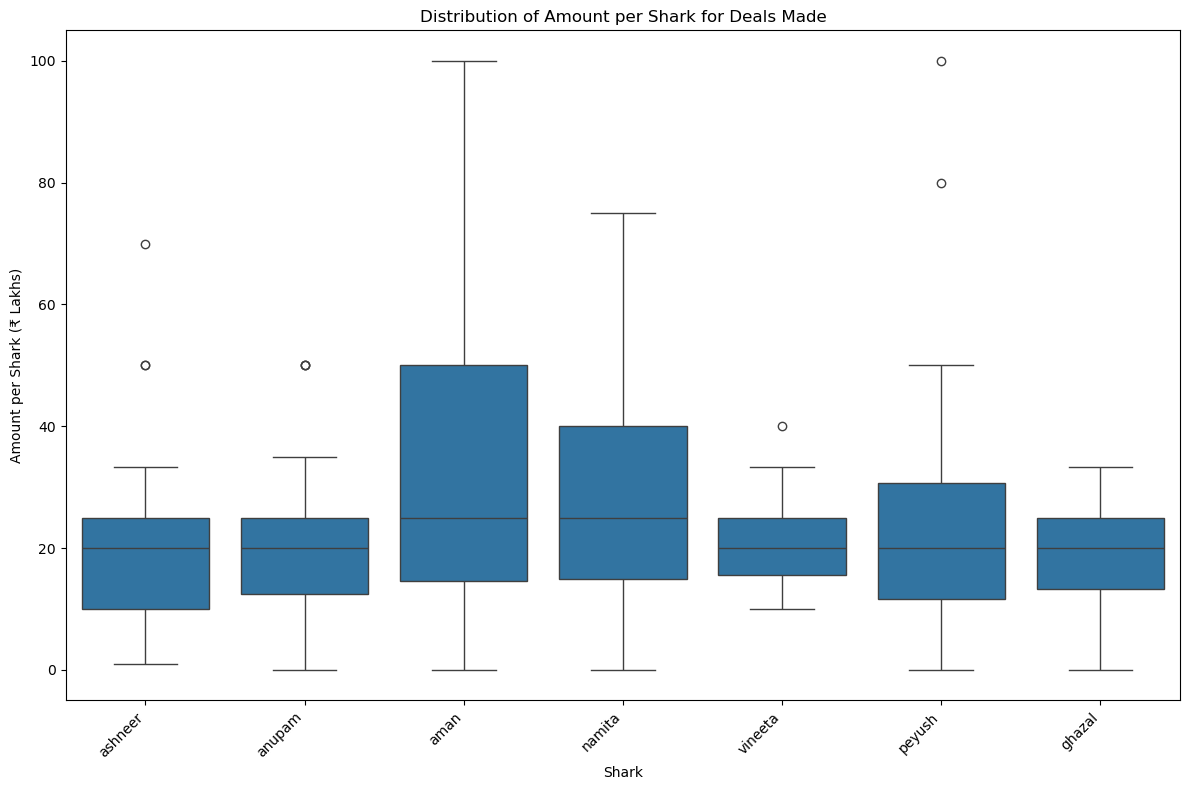

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

shark_deal_columns = ['ashneer_deal', 'anupam_deal', 'aman_deal', 'namita_deal', 'vineeta_deal', 'peyush_deal', 'ghazal_deal']
shark_names = [col.replace('_deal', '') for col in shark_deal_columns]


amount_per_shark_data = []
for shark_col, shark_name in zip(shark_deal_columns, shark_names):
  
    shark_investments = df[df[shark_col] == 1]['amount_per_shark'].dropna()
    
    shark_df = pd.DataFrame({'shark': shark_name, 'amount_per_shark': shark_investments})
    amount_per_shark_data.append(shark_df)


invested_amount_df = pd.concat(amount_per_shark_data)

plt.figure(figsize=(12, 8))
sns.boxplot(x='shark', y='amount_per_shark', data=invested_amount_df)
plt.title('Distribution of Amount per Shark for Deals Made')
plt.xlabel('Shark')
plt.ylabel('Amount per Shark (₹ Lakhs)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Insights : Sharks display different investment personalities:
#### Peyush, Ashneer, and Aman are high and varied investors; Anupam is balanced and rational; Vineeta invests moderately but scales up for strong branding opportunities; and Namita and Ghazal prefer steady, smaller commitments in safer domains.


<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 13. Cases where the deal_amount exceeded the pitcher_ask_amount.</h4>
</div>

In [20]:

deals_exceeding_ask = df[df['deal_amount'] > df['pitcher_ask_amount']]
display(deals_exceeding_ask)


,episode_number,pitch_number,brand_name,idea,deal,pitcher_ask_amount,ask_equity,ask_valuation,deal_amount,deal_equity,...,ashneer_deal,anupam_deal,aman_deal,namita_deal,vineeta_deal,peyush_deal,ghazal_deal,total_sharks_invested,amount_per_shark,equity_per_shark
0,1,1,BluePine Industries,Frozen Momos,1.0,50.0,5.0,1000.0,75.0,16.0,...,1,0,1,0,1,0,0,3,25.000000,5.333333
16,6,16,Skippi Pops,Ice-Pops,NaN,45.0,5.0,900.0,100.0,15.0,...,1,1,1,1,1,0,0,5,20.000000,3.000000
37,13,37,Annie,Braille Literary Device,1.0,30.0,5.0,600.0,105.0,3.0,...,0,1,0,1,0,1,0,3,35.000000,1.000000
39,13,39,The Yarn Bazaar,Yarn-Trading App,1.0,50.0,2.0,2500.0,100.0,10.0,...,1,1,1,0,0,1,0,4,25.000000,2.500000
43,15,43,Hammer Lifestyle,Smart Audio Products,1.0,30.0,3.0,1000.0,100.0,40.0,...,0,0,1,0,0,0,0,1,100.000000,40.000000
59,19,59,WeSTOCK,Livestock health monitoring AI,1.0,50.0,5.0,1000.0,60.0,10.0,...,1,0,1,1,0,1,0,4,15.000000,2.500000
64,20,64,IN A CAN,Can Cocktails,1.0,50.0,2.0,2500.0,100.0,10.0,...,1,1,1,1,0,1,0,5,20.000000,2.000000
76,24,76,The Sass Bar,Gifts,1.0,40.0,8.0,500.0,50.0,35.0,...,0,1,0,0,0,0,1,2,25.000000,17.500000
90,28,89,Humpy A2,Organic Milk Products,1.0,75.0,4.0,1875.0,100.0,15.0,...,0,0,0,0,1,1,1,3,33.333333,5.000000
110,33,109,Tweek Labs,Sportswear,1.0,40.0,2.0,2000.0,60.0,10.0,...,1,1,0,0,0,1,0,3,20.000000,3.333333



<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 14. Shark that has the highest return on investment (ROI) based on deal_amount vs. deal_equity. </h4>
</div> 

In [21]:

successful_deals = df.query("deal > 0 and deal_valuation > 0").copy()


successful_deals['simple_roi'] = (
    successful_deals['deal_valuation'] / (successful_deals['deal_equity'] / 100)
) / successful_deals['deal_amount']


sharks = ['ashneer', 'anupam', 'aman', 'namita', 'vineeta', 'peyush', 'ghazal']


shark_total_roi = {
    s: successful_deals.loc[successful_deals[f'{s}_deal'] == 1, 'simple_roi'].sum()
    for s in sharks
}


highest_shark, highest_roi = max(shark_total_roi.items(), key=lambda x: x[1])

print(f"Shark with the highest total simplified ROI: {highest_shark} with a total ROI of {highest_roi:.2f}")


Shark with the highest total simplified ROI: ashneer with a total ROI of 16432.59



<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 15. Trends in equity distribution over time (lower or higher stakes). </h4>
</div> 

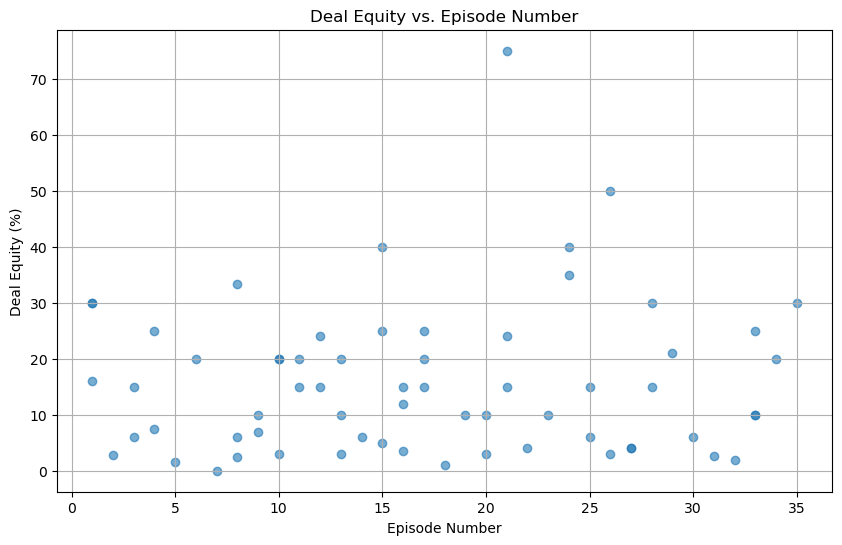

In [22]:

import matplotlib.pyplot as plt

successful_deals_df = df[df['deal'] > 0].copy()

plt.figure(figsize=(10, 6))
plt.scatter(successful_deals_df['episode_number'], successful_deals_df['deal_equity'], alpha=0.6)
plt.title('Deal Equity vs. Episode Number')
plt.xlabel('Episode Number')
plt.ylabel('Deal Equity (%)')
plt.grid(True)
plt.show()


#### While there isn't a perfectly linear trend, it appears that the range of deal equity percentages might be narrower in later episodes compared to earlier episodes. There are some instances of higher equity deals (above 20%) in the earlier episodes, while in later episodes, the majority of deals seem to fall within a lower equity range.
------


<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 16. Relationship between pitcher_ask_amount and deal_amount. </h4>
</div> 

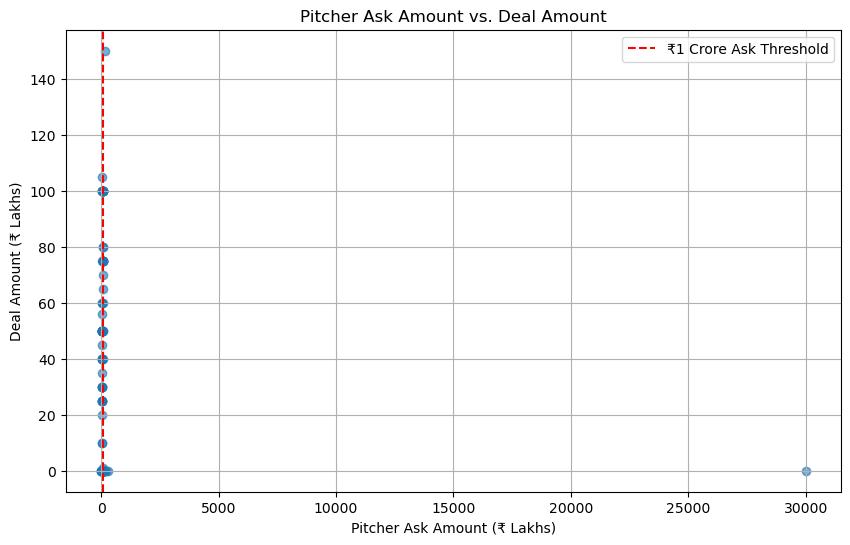

In [23]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['pitcher_ask_amount'], df['deal_amount'], alpha=0.6)
plt.axvline(x=100, color='r', linestyle='--', label='₹1 Crore Ask Threshold')
plt.title('Pitcher Ask Amount vs. Deal Amount')
plt.xlabel('Pitcher Ask Amount (₹ Lakhs)')
plt.ylabel('Deal Amount (₹ Lakhs)')
plt.legend()
plt.grid(True)
plt.show()


#### Pitchers who ask for smaller investments (below ₹50L or ₹1 crore) are much more likely to secure a deal.
#### As the ask amount increases beyond ₹1 crore, the probability of getting a deal drops sharply — nearly to zero in this dataset.
#### So yes — pitchers who ask for less tend to secure more deals.


<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 17. Pattern in episode-wise deal closures. </h4>
</div> 

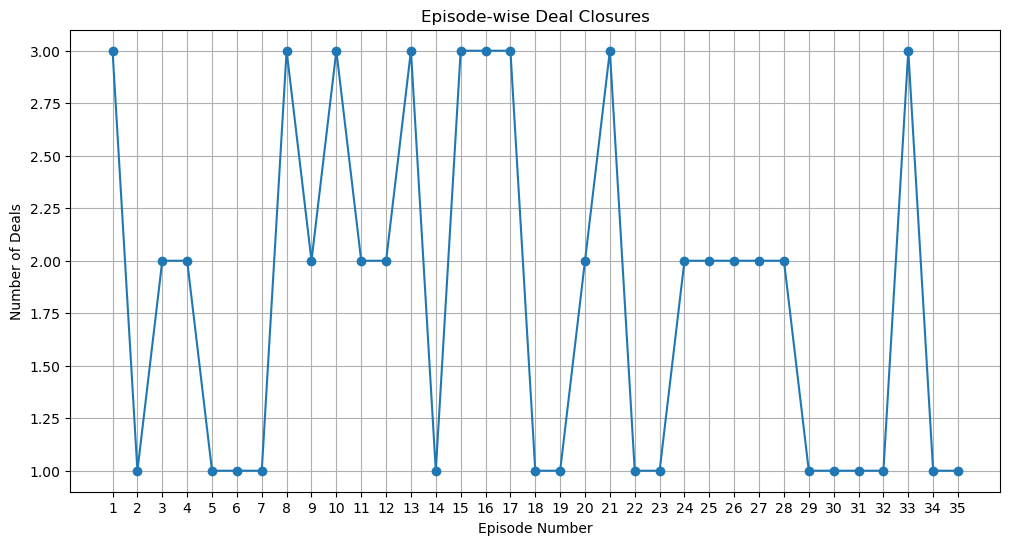

In [24]:

successful_deals_df = df[df['deal'] > 0].copy()
deals_per_episode = successful_deals_df.groupby('episode_number').size().reset_index(name='number_of_deals')

plt.figure(figsize=(12, 6))
plt.plot(deals_per_episode['episode_number'], deals_per_episode['number_of_deals'], marker='o', linestyle='-')
plt.title('Episode-wise Deal Closures')
plt.xlabel('Episode Number')
plt.ylabel('Number of Deals')
plt.xticks(deals_per_episode['episode_number'])
plt.grid(True)
plt.show()


#### There isn’t a strict increasing or decreasing trend, but there are recurring peaks roughly every few episodes where 3 deals occur, indicating that certain episodes attract more investor interest—possibly due to stronger pitches or better-valued startups featured in those episodes.


<h4 style="color: blue; font-weight:700;text-decoration:underline;"> 18. The impact of equity dilution on deal_valuation. </h4>
</div> 

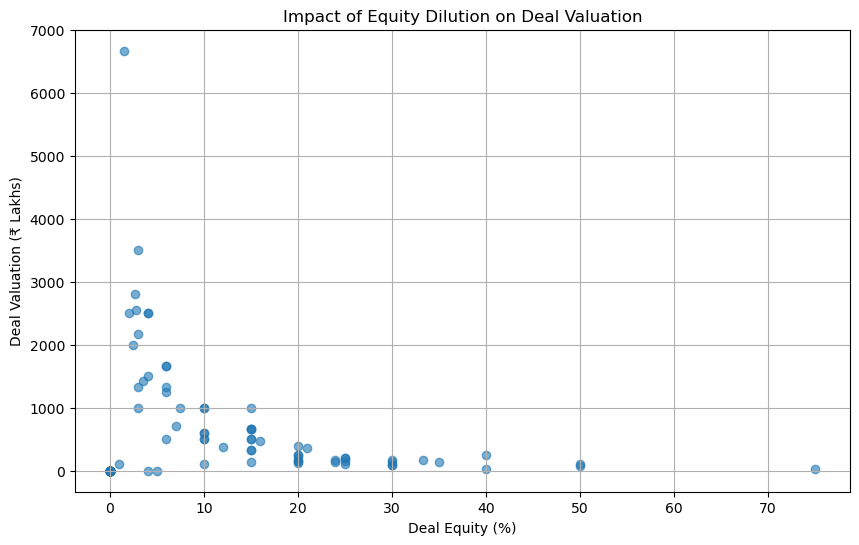

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['deal_equity'], df['deal_valuation'], alpha=0.6)
plt.title('Impact of Equity Dilution on Deal Valuation')
plt.xlabel('Deal Equity (%)')
plt.ylabel('Deal Valuation (₹ Lakhs)')
plt.grid(True)
plt.show()

#### Yes, lower equity asks leading to higher deal valuations.